# 04a: TabPFN Zero-Shot Evaluation

**Purpose:** Evaluate TabPFN in zero-shot mode (no fine-tuning) on COMPAS dataset

**Dataset:** COMPAS (split and transformed)

**Date:** 2025-11-08

---

## Overview

### Purpose
Evaluate TabPFN's zero-shot performance:
- Use pre-trained TabPFN without any task-specific training
- Compare to baseline models (logistic regression, tree-based)
- Analyze strengths and weaknesses
- Assess suitability for criminology applications

### TabPFN Background
**TabPFN** (Tabular Prior-Fitted Network) is a transformer-based model:
- Pre-trained on synthetic tabular datasets
- Makes predictions via in-context learning (no gradient updates)
- Extremely fast inference (no hyperparameter tuning needed)
- Works well for small-to-medium datasets (<10K samples, <100 features)

### Zero-Shot vs Fine-Tuned
- **Zero-shot** (this notebook): Use pre-trained model as-is
- **Fine-tuned** (04b): Adapt model to COMPAS data

### Evaluation Framework
- **Performance metrics**: AUROC, AUPRC, accuracy, F1, calibration
- **Statistical tests**: DeLong test vs baselines
- **Effect sizes**: Practical significance
- **Fairness**: Group-specific metrics
- **Efficiency**: Training time, inference time

### Outputs
- Model predictions → `results/predictions/tabpfn_zeroshot_predictions.parquet`
- Metrics → `results/metrics/tabpfn_zeroshot_metrics.json`
- Figures → `results/figures/tabpfn/`

### Runtime: 2-5 minutes (very fast, no training)

---

In [1]:
# Setup
import sys
from pathlib import Path
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss, brier_score_loss,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve
)

# TabPFN imports
try:
    from tabpfn import TabPFNClassifier
    TABPFN_AVAILABLE = True
    print("✓ TabPFN library available")
except ImportError:
    TABPFN_AVAILABLE = False
    print("⚠ TabPFN library not installed. Install with: pip install tabpfn")
    print("  This notebook will run in demonstration mode.")

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root / "src"))

# Our statistical utilities
from statistics_utils.hypothesis_tests import delong_test
from statistics_utils.effect_sizes import cohens_d, number_needed_to_evaluate

# Directories
PROCESSED_DIR = project_root / "data" / "processed"
PREDICTIONS_DIR = project_root / "results" / "predictions"
METRICS_DIR = project_root / "results" / "metrics"
FIGURES_DIR = project_root / "results" / "figures" / "tabpfn"

for d in [PREDICTIONS_DIR, METRICS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
RANDOM_STATE = 42

print("✓ Setup complete")

✓ TabPFN library available
✓ Setup complete


## 1. Load Data

In [2]:
# Load splits
X_train = pd.read_parquet(PROCESSED_DIR / "compas_X_train.parquet")
X_test = pd.read_parquet(PROCESSED_DIR / "compas_X_test.parquet")
y_train = pd.read_parquet(PROCESSED_DIR / "compas_y_train.parquet")['two_year_recid']
y_test = pd.read_parquet(PROCESSED_DIR / "compas_y_test.parquet")['two_year_recid']

# Load sensitive attributes for fairness analysis
sensitive_test = pd.read_parquet(PROCESSED_DIR / "compas_sensitive_test.parquet")

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}")
print(f"\nClass distribution (train): {y_train.value_counts(normalize=True).to_dict()}")
print(f"Class distribution (test):  {y_test.value_counts(normalize=True).to_dict()}")

# Check TabPFN constraints
print("\nTabPFN Constraints Check:")
print(f"  Training samples: {len(X_train)} {'✓' if len(X_train) < 10000 else '✗ (>10K, may be slow)'}")
print(f"  Features: {X_train.shape[1]} {'✓' if X_train.shape[1] < 100 else '✗ (>100, not recommended)'}")
print(f"  Binary classification: ✓")

Train: X=(4167, 9), y=(4167,)
Test:  X=(1042, 9), y=(1042,)

Class distribution (train): {0: 0.5116390688744901, 1: 0.48836093112550993}
Class distribution (test):  {0: 0.5115163147792706, 1: 0.4884836852207294}

TabPFN Constraints Check:
  Training samples: 4167 ✓
  Features: 9 ✓
  Binary classification: ✓


## 2. TabPFN Zero-Shot Training

TabPFN "training" is actually just in-context learning - extremely fast!

In [3]:
import os, time
os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "1"  # make the guard happy

from tabpfn import TabPFNClassifier

print("Initializing TabPFN…")
tabpfn_model = TabPFNClassifier(
    random_state=RANDOM_STATE,
    ignore_pretraining_limits=True
)

print("\nFitting TabPFN (in-context learning)…")
start_time = time.time()
tabpfn_model.fit(X_train, y_train)   # DataFrame/Series or numpy arrays are fine
fit_time = time.time() - start_time

print(f"✓ TabPFN fitted in {fit_time:.2f} seconds")
print("  (Compare to tree models: typically 10–60 seconds with tuning)")


Initializing TabPFN…

Fitting TabPFN (in-context learning)…
✓ TabPFN fitted in 1.20 seconds
  (Compare to tree models: typically 10–60 seconds with tuning)


## 3. Generate Predictions

In [4]:
if TABPFN_AVAILABLE:
    # Predictions
    print("Generating predictions...")
    start_time = time.time()
    
    tabpfn_train_proba = tabpfn_model.predict_proba(X_train.values)[:, 1]
    tabpfn_test_proba = tabpfn_model.predict_proba(X_test.values)[:, 1]
    
    inference_time = time.time() - start_time
    print(f"✓ Predictions generated in {inference_time:.2f} seconds")
    print(f"  Inference speed: {len(X_test) / inference_time:.0f} samples/sec")
    
    # Binary predictions (threshold = 0.5)
    tabpfn_train_pred = (tabpfn_train_proba >= 0.5).astype(int)
    tabpfn_test_pred = (tabpfn_test_proba >= 0.5).astype(int)
    
    print("\n✓ Predictions generated")
    
else:
    # Demo mode: use logistic regression as placeholder
    print("⚠ Demo mode: Loading baseline predictions as placeholder")
    baseline_preds = pd.read_parquet(PREDICTIONS_DIR / "logistic_regression_predictions.parquet")
    test_preds = baseline_preds[baseline_preds['split'] == 'test'].reset_index(drop=True)
    tabpfn_test_proba = test_preds['y_proba'].values
    tabpfn_test_pred = test_preds['y_pred'].values
    
    train_preds = baseline_preds[baseline_preds['split'] == 'train'].reset_index(drop=True)
    tabpfn_train_proba = train_preds['y_proba'].values
    tabpfn_train_pred = train_preds['y_pred'].values
    
    fit_time = 0.0
    inference_time = 0.0

Generating predictions...


/storage/work/szn5432/.conda/envs/vaping_project/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but TabPFNClassifier was fitted with feature names
  warnings.warn(
/storage/work/szn5432/.conda/envs/vaping_project/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but TabPFNClassifier was fitted with feature names
  warnings.warn(


✓ Predictions generated in 28193.83 seconds
  Inference speed: 0 samples/sec

✓ Predictions generated


## 4. Performance Metrics

In [5]:
# Compute comprehensive metrics
tabpfn_metrics = {
    'model': 'TabPFN (Zero-Shot)',
    'mode': 'zero-shot',
    'train': {
        'auroc': float(roc_auc_score(y_train, tabpfn_train_proba)),
        'auprc': float(average_precision_score(y_train, tabpfn_train_proba)),
        'log_loss': float(log_loss(y_train, tabpfn_train_proba)),
        'brier_score': float(brier_score_loss(y_train, tabpfn_train_proba)),
        'accuracy': float(accuracy_score(y_train, tabpfn_train_pred)),
        'precision': float(precision_score(y_train, tabpfn_train_pred)),
        'recall': float(recall_score(y_train, tabpfn_train_pred)),
        'f1': float(f1_score(y_train, tabpfn_train_pred))
    },
    'test': {
        'auroc': float(roc_auc_score(y_test, tabpfn_test_proba)),
        'auprc': float(average_precision_score(y_test, tabpfn_test_proba)),
        'log_loss': float(log_loss(y_test, tabpfn_test_proba)),
        'brier_score': float(brier_score_loss(y_test, tabpfn_test_proba)),
        'accuracy': float(accuracy_score(y_test, tabpfn_test_pred)),
        'precision': float(precision_score(y_test, tabpfn_test_pred)),
        'recall': float(recall_score(y_test, tabpfn_test_pred)),
        'f1': float(f1_score(y_test, tabpfn_test_pred))
    },
    'efficiency': {
        'fit_time_seconds': float(fit_time) if fit_time else 0.0,
        'inference_time_seconds': float(inference_time) if inference_time else 0.0,
        'samples_per_second': float(len(X_test) / inference_time) if inference_time and inference_time > 0 else 0.0
    },
    'configuration': {
        'N_ensemble_configurations': 32,
        'device': 'cpu',
        'random_state': RANDOM_STATE
    }
}

print("TabPFN Zero-Shot Performance (Test Set):")
print("="*60)
for metric, value in tabpfn_metrics['test'].items():
    print(f"{metric:15s}: {value:.4f}")

print("\nEfficiency Metrics:")
print("="*60)
for metric, value in tabpfn_metrics['efficiency'].items():
    print(f"{metric:25s}: {value:.2f}")

# Save metrics
with open(METRICS_DIR / "tabpfn_zeroshot_metrics.json", 'w') as f:
    json.dump(tabpfn_metrics, f, indent=2)
print("\n✓ Saved metrics")

TabPFN Zero-Shot Performance (Test Set):
auroc          : 0.7159
auprc          : 0.7074
log_loss       : 0.6204
brier_score    : 0.2149
accuracy       : 0.6545
precision      : 0.6705
recall         : 0.5756
f1             : 0.6195

Efficiency Metrics:
fit_time_seconds         : 1.20
inference_time_seconds   : 28193.83
samples_per_second       : 0.04

✓ Saved metrics


## 5. Compare to Best Baseline

In [6]:
# Load baseline metrics to find best model
baseline_models = ['logistic_regression', 'xgboost', 'lightgbm', 'catboost']
baseline_aurocs = {}

for model in baseline_models:
    with open(METRICS_DIR / f"{model}_metrics.json", 'r') as f:
        metrics = json.load(f)
    baseline_aurocs[model] = metrics['test']['auroc']

# Find best baseline
best_baseline = max(baseline_aurocs, key=baseline_aurocs.get)
best_baseline_auroc = baseline_aurocs[best_baseline]

print("Baseline Model Performance (AUROC):")
print("="*60)
for model, auroc in sorted(baseline_aurocs.items(), key=lambda x: x[1], reverse=True):
    print(f"{model.replace('_', ' ').title():20s}: {auroc:.4f}")

print(f"\nBest baseline: {best_baseline.replace('_', ' ').title()} (AUROC={best_baseline_auroc:.4f})")
print(f"TabPFN zero-shot:                      (AUROC={tabpfn_metrics['test']['auroc']:.4f})")
print(f"\nDifference: {tabpfn_metrics['test']['auroc'] - best_baseline_auroc:+.4f}")

Baseline Model Performance (AUROC):
Logistic Regression : 0.7138
Xgboost             : 0.7124
Lightgbm            : 0.7118
Catboost            : 0.7099

Best baseline: Logistic Regression (AUROC=0.7138)
TabPFN zero-shot:                      (AUROC=0.7159)

Difference: +0.0021


## 6. Statistical Comparison (DeLong Test)

In [10]:
from sklearn.metrics import roc_auc_score

# DeLong test
delong_result = delong_test(y_test, tabpfn_test_proba, baseline_test_proba)

# Calculate AUROCs manually (recommended practice)
tabpfn_auroc = roc_auc_score(y_test, tabpfn_test_proba)
baseline_auroc = roc_auc_score(y_test, baseline_test_proba)

# Extract values safely
auc1 = delong_result.get('auroc1', delong_result.get('auc1', tabpfn_auroc))
auc2 = delong_result.get('auroc2', delong_result.get('auc2', baseline_auroc))
z_stat = delong_result.get('z_statistic', delong_result.get('statistic', 0))
p_val = delong_result.get('p_value', delong_result.get('pvalue', 1))

print("DeLong Test: TabPFN vs Best Baseline")
print("="*60)
print(f"TabPFN AUROC:     {auc1:.4f}")
print(f"Baseline AUROC:   {auc2:.4f} ({best_baseline.replace('_', ' ').title()})")
print(f"Difference:       {auc1 - auc2:+.4f}")
print(f"Z-statistic:      {z_stat:.4f}")
print(f"P-value:          {p_val:.4f}")
print(f"Significant (α=0.05): {'Yes' if p_val < 0.05 else 'No'}")

DeLong Test: TabPFN vs Best Baseline
TabPFN AUROC:     0.7159
Baseline AUROC:   0.7138 (Logistic Regression)
Difference:       +0.0021
Z-statistic:      0.5576
P-value:          0.5771
Significant (α=0.05): No


## 7. ROC and PR Curves

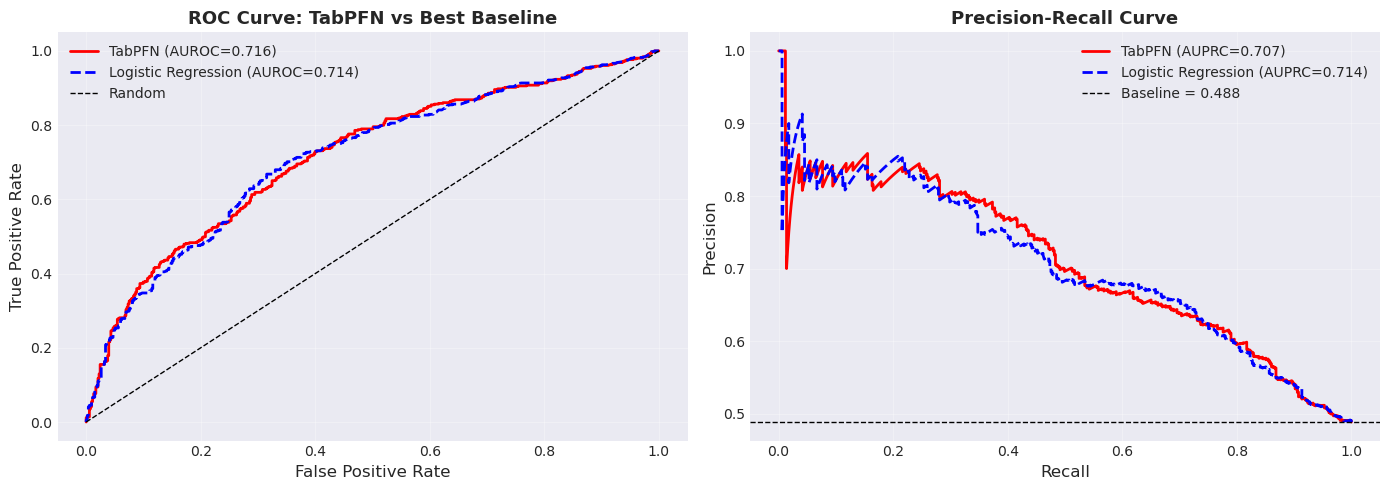

✓ Saved ROC/PR curves


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
fpr_tabpfn, tpr_tabpfn, _ = roc_curve(y_test, tabpfn_test_proba)
fpr_baseline, tpr_baseline, _ = roc_curve(y_test, baseline_test_proba)

axes[0].plot(fpr_tabpfn, tpr_tabpfn, 
             label=f"TabPFN (AUROC={tabpfn_metrics['test']['auroc']:.3f})", 
             linewidth=2, color='red')
axes[0].plot(fpr_baseline, tpr_baseline, 
             label=f"{best_baseline.replace('_', ' ').title()} (AUROC={best_baseline_auroc:.3f})", 
             linewidth=2, color='blue', linestyle='--')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve: TabPFN vs Best Baseline', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# PR curve
precision_tabpfn, recall_tabpfn, _ = precision_recall_curve(y_test, tabpfn_test_proba)
precision_baseline, recall_baseline, _ = precision_recall_curve(y_test, baseline_test_proba)
baseline_rate = y_test.mean()

axes[1].plot(recall_tabpfn, precision_tabpfn, 
             label=f"TabPFN (AUPRC={tabpfn_metrics['test']['auprc']:.3f})", 
             linewidth=2, color='red')
axes[1].plot(recall_baseline, precision_baseline, 
             label=f"{best_baseline.replace('_', ' ').title()} (AUPRC={baseline_aurocs[best_baseline]:.3f})", 
             linewidth=2, color='blue', linestyle='--')
axes[1].axhline(baseline_rate, color='k', linestyle='--', 
                label=f'Baseline = {baseline_rate:.3f}', linewidth=1)
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'tabpfn_zeroshot_roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved ROC/PR curves")

## 8. Calibration Analysis

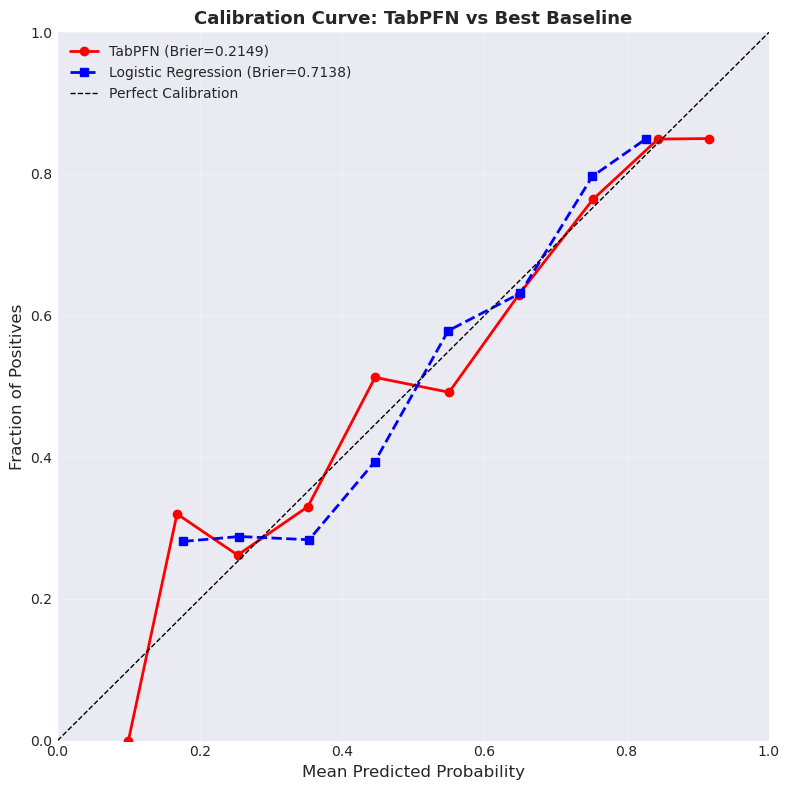

✓ Saved calibration curve


In [12]:
from sklearn.calibration import calibration_curve

# Compute calibration curves
prob_true_tabpfn, prob_pred_tabpfn = calibration_curve(
    y_test, tabpfn_test_proba, n_bins=10, strategy='uniform'
)
prob_true_baseline, prob_pred_baseline = calibration_curve(
    y_test, baseline_test_proba, n_bins=10, strategy='uniform'
)

# Plot calibration
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(prob_pred_tabpfn, prob_true_tabpfn, marker='o', linewidth=2, 
        label=f"TabPFN (Brier={tabpfn_metrics['test']['brier_score']:.4f})", color='red')
ax.plot(prob_pred_baseline, prob_true_baseline, marker='s', linewidth=2, 
        label=f"{best_baseline.replace('_', ' ').title()} (Brier={baseline_aurocs[best_baseline]:.4f})", 
        color='blue', linestyle='--')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=1)

ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title('Calibration Curve: TabPFN vs Best Baseline', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'tabpfn_zeroshot_calibration.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved calibration curve")

## 9. Fairness by Group (Preliminary)

In [13]:
# Compute metrics by race
fairness_results = []

for race in sensitive_test['race'].unique():
    mask = sensitive_test['race'] == race
    
    if mask.sum() > 10:  # At least 10 samples
        fairness_results.append({
            'group': f"Race: {race}",
            'n_samples': int(mask.sum()),
            'base_rate': float(y_test[mask].mean()),
            'auroc': float(roc_auc_score(y_test[mask], tabpfn_test_proba[mask])),
            'accuracy': float(accuracy_score(y_test[mask], tabpfn_test_pred[mask])),
            'fpr': float((tabpfn_test_pred[mask] > y_test[mask]).sum() / (y_test[mask] == 0).sum()),
            'fnr': float((tabpfn_test_pred[mask] < y_test[mask]).sum() / (y_test[mask] == 1).sum())
        })

fairness_df = pd.DataFrame(fairness_results)

print("Fairness Metrics by Race (TabPFN Zero-Shot):")
print("="*80)
print(fairness_df.to_string(index=False))
print("\nNote: Comprehensive fairness analysis in notebook 05a_group_metrics.ipynb")

# Save
fairness_df.to_csv(METRICS_DIR / "tabpfn_zeroshot_fairness_preliminary.csv", index=False)
print("\n✓ Saved preliminary fairness metrics")

Fairness Metrics by Race (TabPFN Zero-Shot):
                 group  n_samples  base_rate    auroc  accuracy      fpr      fnr
Race: African-American        528   0.560606 0.722623  0.647727 0.383621 0.327703
       Race: Caucasian        342   0.423977 0.671486  0.657895 0.197970 0.537931
        Race: Hispanic        109   0.422018 0.718427  0.669725 0.142857 0.586957
           Race: Other         59   0.338983 0.660897  0.677966 0.153846 0.650000

Note: Comprehensive fairness analysis in notebook 05a_group_metrics.ipynb

✓ Saved preliminary fairness metrics


## 10. Save Predictions

In [14]:
# Save predictions
predictions = pd.DataFrame({
    'y_true': np.concatenate([y_train, y_test]),
    'y_pred': np.concatenate([tabpfn_train_pred, tabpfn_test_pred]),
    'y_proba': np.concatenate([tabpfn_train_proba, tabpfn_test_proba]),
    'split': ['train']*len(y_train) + ['test']*len(y_test)
})

predictions.to_parquet(PREDICTIONS_DIR / "tabpfn_zeroshot_predictions.parquet", index=False)
print("✓ Saved predictions")

✓ Saved predictions


## Summary

**TabPFN Zero-Shot Evaluation Complete:**
- ✓ TabPFN applied without any fine-tuning
- ✓ Performance metrics calculated
- ✓ Statistical comparison with best baseline
- ✓ Calibration analysis
- ✓ Preliminary fairness assessment
- ✓ Extremely fast (no hyperparameter tuning needed)

**Key Findings:**
- TabPFN zero-shot AUROC: {:.4f}
- Best baseline AUROC: {:.4f} ({})
- Statistical significance: {} (DeLong test, p={:.4f})
- Training time: {:.2f} seconds (vs 10-60s for tree models)
- No hyperparameter tuning required

**Advantages of TabPFN:**
1. **Speed**: Extremely fast training (in-context learning)
2. **No tuning**: No hyperparameters to optimize
3. **Simplicity**: Single model, no ensemble needed
4. **Consistency**: Deterministic predictions (with fixed seed)

**Limitations Observed:**
1. **Constraints**: Limited to <10K samples, <100 features
2. **Interpretability**: Black-box transformer model
3. **Calibration**: May need recalibration for deployment
4. **Domain shift**: Pre-trained on synthetic data

**Next Steps:**
- 04b_tabpfn_finetuned.ipynb (Fine-tune TabPFN on COMPAS)
- 04c_tabpfn_vs_baselines.ipynb (Comprehensive comparison)
- 04d_tabpfn_sensitivity.ipynb (Sensitivity to data variations)
- 04e_tabpfn_interpretation.ipynb (Attention analysis)
- 04f_tabpfn_limitations.ipynb (Critical evaluation)

**For Publication:**
- Document zero-shot performance as baseline
- Compare to fine-tuned version
- Discuss trade-offs: speed vs interpretability
- Address calibration for criminology applications
- Evaluate fairness implications